<a href="https://colab.research.google.com/github/shristea7/College-Dump/blob/main/AI_Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import heapq
import matplotlib.pyplot as plt
from collections import deque
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


In [ ]:
def manhattan_distance(state, goal):
    distance = 0
    for tile in range(1, 9):
        curr = state.index(tile)
        goal_pos = goal.index(tile)
        distance += abs(curr//3 - goal_pos//3) + abs(curr%3 - goal_pos%3)
    return distance

def misplaced_tiles(state, goal):
    return sum(1 for i in range(9) if state[i] != 0 and state[i] != goal[i])


In [ ]:
def get_neighbors(state):
    neighbors = []
    idx = state.index(0)
    row, col = idx // 3, idx % 3

    moves = [(-1,0), (1,0), (0,-1), (0,1)]  # Up, Down, Left, Right

    for r, c in moves:
        new_r, new_c = row + r, col + c
        if 0 <= new_r < 3 and 0 <= new_c < 3:
            new_idx = new_r * 3 + new_c
            new_state = state[:]
            new_state[idx], new_state[new_idx] = new_state[new_idx], new_state[idx]
            neighbors.append(new_state)

    return neighbors

In [ ]:
def is_solvable(state):
    inv_count = 0
    arr = [x for x in state if x != 0]
    for i in range(len(arr)):
        for j in range(i+1, len(arr)):
            if arr[i] > arr[j]:
                inv_count += 1
    return inv_count % 2 == 0

In [ ]:
def greedy_best_first_search(start, goal, heuristic):
    if not is_solvable(start):
        print("Puzzle is unsolvable!")
        return None, 0

    pq = []
    heapq.heappush(pq, (heuristic(start, goal), start))
    visited = set()
    parent = {tuple(start): None}
    nodes_expanded = 0

    while pq:
        _, current = heapq.heappop(pq)
        nodes_expanded += 1

        if current == goal:
            path = []
            while current is not None:
                path.append(current)
                current = parent[tuple(current)]
            return path[::-1], nodes_expanded

        visited.add(tuple(current))

        for neighbor in get_neighbors(current):
            if tuple(neighbor) not in visited:
                parent[tuple(neighbor)] = current
                heapq.heappush(pq, (heuristic(neighbor, goal), neighbor))

    return None, nodes_expanded


In [ ]:
def bfs(start, goal):
    queue = deque([start])
    visited = set([tuple(start)])
    parent = {tuple(start): None}
    nodes = 0

    while queue:
        current = queue.popleft()
        nodes += 1

        if current == goal:
            path = []
            while current is not None:
                path.append(current)
                current = parent[tuple(current)]
            return path[::-1], nodes
        for neighbor in get_neighbors(current):
            if tuple(neighbor) not in visited:
                visited.add(tuple(neighbor))
                parent[tuple(neighbor)] = current
                queue.append(neighbor)


In [ ]:
def dfs(start, goal, depth_limit=50):
    stack = [(start, 0)]
    visited = set()
    parent = {tuple(start): None}
    nodes = 0

    while stack:
        current, depth = stack.pop()
        nodes += 1

        if current == goal:
            path = []
            while current is not None:
                path.append(current)
                current = parent[tuple(current)]
            return path[::-1], nodes

        if depth < depth_limit:
            visited.add(tuple(current))
            for neighbor in get_neighbors(current):
                if tuple(neighbor) not in visited:
                    parent[tuple(neighbor)] = current
                    stack.append((neighbor, depth+1))


In [ ]:
print("Enter the 8-Puzzle configuration (use 0 for blank):")
user_input = []
for i in range(3):
    row = list(map(int, input(f"Enter row {i+1}: ").split()))
    user_input.extend(row)

if sorted(user_input) != list(range(9)):
    print("\n Invalid input! Enter numbers from 0 to 8 without repetition.")
    exit()

start_state = user_input
goal_state = [1, 2, 3, 4, 5, 6, 7, 8, 0]

Enter the 8-Puzzle configuration (use 0 for blank):
Enter row 1: 1 2 3
Enter row 2: 0 4 6
Enter row 3: 7 5 8


In [ ]:

def display_grid(state):
    """
    Displays the 8-puzzle as a proper 3x3 tile grid.
    0 represents the blank tile.
    """
    grid = [state[i:i+3] for i in range(0, 9, 3)]

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("8-Puzzle State")

    for i in range(3):
        for j in range(3):
            value = grid[i][j]

            # Draw tile box
            rect = Rectangle((j, 2 - i), 1, 1,
                             fill=True,
                             edgecolor='black',
                             facecolor='lightgray')
            ax.add_patch(rect)

            # Draw tile number (skip blank)
            if value != 0:
                ax.text(j + 0.5, 2 - i + 0.5, str(value),
                        ha='center', va='center',
                        fontsize=18,
                        fontweight='bold')

    plt.show()



Initial State:


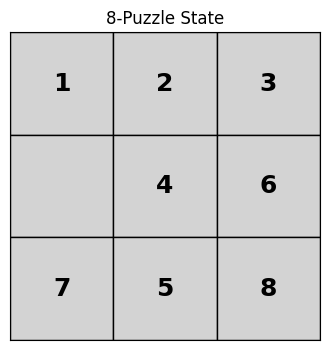


PERFORMANCE COMPARISON

GBFS (Manhattan Distance)
Steps: 3 Nodes Expanded: 4

BFS
Steps: 3 Nodes Expanded: 17

DFS
Steps: 37 Nodes Expanded: 15116

SOLUTION PATH (GBFS - Manhattan Distance)

Step 0


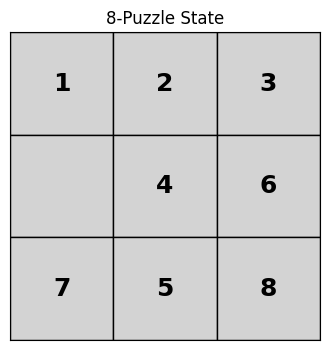

Step 1


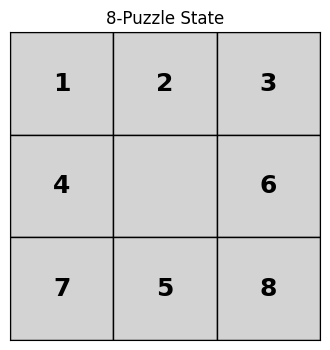

Step 2


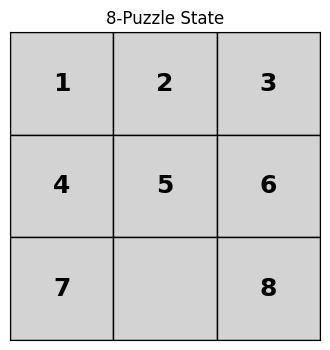

Step 3


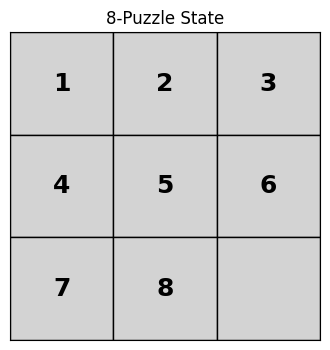

In [ ]:

print("\nInitial State:")
display_grid(start_state)
gbfs_path, gbfs_nodes = greedy_best_first_search(
    start_state, goal_state, manhattan_distance)

if gbfs_path:
    bfs_path, bfs_nodes = bfs(start_state, goal_state)
    dfs_path, dfs_nodes = dfs(start_state, goal_state)

    print("\nPERFORMANCE COMPARISON\n")
    print("GBFS (Manhattan Distance)")
    print("Steps:", len(gbfs_path)-1, "Nodes Expanded:", gbfs_nodes)

    print("\nBFS")
    print("Steps:", len(bfs_path)-1, "Nodes Expanded:", bfs_nodes)

    print("\nDFS")
    print("Steps:", len(dfs_path)-1, "Nodes Expanded:", dfs_nodes)

    print("\nSOLUTION PATH (GBFS - Manhattan Distance)\n")
    for step, state in enumerate(gbfs_path):
        print("Step", step)
        display_grid(state)